<a href="https://colab.research.google.com/github/Zezo-Elkafoury/Fifa-world-cup-analysis-and-prediction/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Loading Data

In [2]:
df = pd.read_csv('/content/matches_1930_2022.csv')


# Data wrangling and cleaning

In [3]:
df.head()

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,...,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,...,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   home_team                        964 non-null    object 
 1   away_team                        964 non-null    object 
 2   home_score                       964 non-null    int64  
 3   home_xg                          128 non-null    float64
 4   home_penalty                     35 non-null     float64
 5   away_score                       964 non-null    int64  
 6   away_xg                          128 non-null    float64
 7   away_penalty                     35 non-null     float64
 8   home_manager                     964 non-null    object 
 9   home_captain                     644 non-null    object 
 10  away_manager                     964 non-null    object 
 11  away_captain                     644 non-null    object 
 12  Attendance            

## There are many columns that has mostof their values are NaNs

In [5]:
# Calculate the percentage of missing values for each column
missing_percentages = df.isnull().sum() / len(df) * 100

# Identify columns to drop
columns_to_drop = missing_percentages[missing_percentages > 70].index.tolist()

print(f"Columns to drop due to more than 70% missing values: {columns_to_drop}")

# Drop the identified columns
df = df.drop(columns=columns_to_drop)

df.head()

Columns to drop due to more than 70% missing values: ['home_xg', 'home_penalty', 'away_xg', 'away_penalty', 'Notes', 'home_own_goal', 'away_own_goal', 'home_penalty_goal', 'away_penalty_goal', 'home_penalty_miss_long', 'away_penalty_miss_long', 'home_penalty_shootout_goal_long', 'away_penalty_shootout_goal_long', 'home_penalty_shootout_miss_long', 'away_penalty_shootout_miss_long', 'home_red_card', 'away_red_card', 'home_yellow_red_card', 'away_yellow_red_card']


,home_team,away_team,home_score,away_score,home_manager,home_captain,away_manager,away_captain,Attendance,Venue,...,Host,Year,home_goal,away_goal,home_goal_long,away_goal_long,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3,Lionel Scaloni,Lionel Messi,Didier Deschamps,Hugo Lloris,88966,"Lusail Iconic Stadium, Lusail",...,Qatar,2022,Ángel Di María · 36|Lionel Messi · 108,Kylian Mbappé · 81,['36&rsquor;|2:0|Ángel Di María|Assist:|Alexis...,['81&rsquor;|2:2|Kylian Mbappé|Assist:|Marcus ...,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,1,Zlatko Dalić,Luka Modrić,Hoalid Regragui,Hakim Ziyech,44137,"Khalifa International Stadium, Doha",...,Qatar,2022,Joško Gvardiol · 7|Mislav Oršić · 42,Achraf Dari · 9,['7&rsquor;|1:0|Joško Gvardiol|Assist:|Ivan Pe...,['9&rsquor;|1:1|Achraf Dari'],NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,0,Didier Deschamps,Hugo Lloris,Hoalid Regragui,Romain Saïss,68294,"Al Bayt Stadium, Al Khor",...,Qatar,2022,Theo Hernández · 5|Randal Kolo Muani · 79,NaN,"['5&rsquor;|1:0|Theo Hernández', '79&rsquor;|2...",NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,0,Lionel Scaloni,Lionel Messi,Zlatko Dalić,Luka Modrić,88966,"Lusail Iconic Stadium, Lusail",...,Qatar,2022,Julián Álvarez · 39|Julián Álvarez · 69,NaN,"['39&rsquor;|2:0|Julián Álvarez', '69&rsquor;|...",NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,0,Hoalid Regragui,Romain Saïss,Fernando Santos,Pepe,44198,"Al Thumama Stadium, ath-Thumāma",...,Qatar,2022,Youssef En-Nesyri · 42,NaN,['42&rsquor;|1:0|Youssef En-Nesyri|Assist:|Yah...,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


In [6]:
# Convert the 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Display the info of the cleaned DataFrame to check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   home_team                964 non-null    object        
 1   away_team                964 non-null    object        
 2   home_score               964 non-null    int64         
 3   away_score               964 non-null    int64         
 4   home_manager             964 non-null    object        
 5   home_captain             644 non-null    object        
 6   away_manager             964 non-null    object        
 7   away_captain             644 non-null    object        
 8   Attendance               964 non-null    int64         
 9   Venue                    964 non-null    object        
 10  Officials                709 non-null    object        
 11  Round                    964 non-null    object        
 12  Date                     964 non-nul

### Handling Remaining Missing Values

In [7]:
# Identify columns that still have missing values after the initial drop
remaining_missing = df.isnull().sum()
columns_to_impute = remaining_missing[remaining_missing > 0].index.tolist()

print(f"Columns with remaining missing values: {columns_to_impute}")

# Impute specific columns

# For 'home_captain', 'away_captain', 'Officials', 'Referee', we'll fill with 'Unknown'
for col in ['home_captain', 'away_captain', 'Officials', 'Referee']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# For descriptive '_goal', '_goal_long', '_yellow_card_long', '_substitute_in_long' columns, fill with empty string
for col in ['home_goal', 'away_goal', 'home_goal_long', 'away_goal_long',
            'home_yellow_card_long', 'away_yellow_card_long',
            'home_substitute_in_long', 'away_substitute_in_long']:
    if col in df.columns:
        df[col] = df[col].fillna('')

# Display info again to confirm all NaNs are handled
df.info()

Columns with remaining missing values: ['home_captain', 'away_captain', 'Officials', 'Referee', 'home_goal', 'away_goal', 'home_goal_long', 'away_goal_long', 'home_yellow_card_long', 'away_yellow_card_long', 'home_substitute_in_long', 'away_substitute_in_long']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   home_team                964 non-null    object        
 1   away_team                964 non-null    object        
 2   home_score               964 non-null    int64         
 3   away_score               964 non-null    int64         
 4   home_manager             964 non-null    object        
 5   home_captain             964 non-null    object        
 6   away_manager             964 non-null    object        
 7   away_captain             964 non-null    object        
 8   Attendance        

In [8]:
# Display a sample of the updated DataFrame
df.head()

,home_team,away_team,home_score,away_score,home_manager,home_captain,away_manager,away_captain,Attendance,Venue,...,Host,Year,home_goal,away_goal,home_goal_long,away_goal_long,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3,Lionel Scaloni,Lionel Messi,Didier Deschamps,Hugo Lloris,88966,"Lusail Iconic Stadium, Lusail",...,Qatar,2022,Ángel Di María · 36|Lionel Messi · 108,Kylian Mbappé · 81,['36&rsquor;|2:0|Ángel Di María|Assist:|Alexis...,['81&rsquor;|2:2|Kylian Mbappé|Assist:|Marcus ...,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,1,Zlatko Dalić,Luka Modrić,Hoalid Regragui,Hakim Ziyech,44137,"Khalifa International Stadium, Doha",...,Qatar,2022,Joško Gvardiol · 7|Mislav Oršić · 42,Achraf Dari · 9,['7&rsquor;|1:0|Joško Gvardiol|Assist:|Ivan Pe...,['9&rsquor;|1:1|Achraf Dari'],,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,0,Didier Deschamps,Hugo Lloris,Hoalid Regragui,Romain Saïss,68294,"Al Bayt Stadium, Al Khor",...,Qatar,2022,Theo Hernández · 5|Randal Kolo Muani · 79,,"['5&rsquor;|1:0|Theo Hernández', '79&rsquor;|2...",,,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,0,Lionel Scaloni,Lionel Messi,Zlatko Dalić,Luka Modrić,88966,"Lusail Iconic Stadium, Lusail",...,Qatar,2022,Julián Álvarez · 39|Julián Álvarez · 69,,"['39&rsquor;|2:0|Julián Álvarez', '69&rsquor;|...",,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,0,Hoalid Regragui,Romain Saïss,Fernando Santos,Pepe,44198,"Al Thumama Stadium, ath-Thumāma",...,Qatar,2022,Youssef En-Nesyri · 42,,['42&rsquor;|1:0|Youssef En-Nesyri|Assist:|Yah...,,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


In [9]:
df.describe()

,home_score,away_score,Attendance,Date,Year
count,964.000000,964.000000,964.000000,964,964.000000
mean,1.776971,1.044606,45693.374481,1989-09-28 05:07:43.070539264,1989.244813
min,0.000000,0.000000,2000.000000,1930-07-13 00:00:00,1930.000000
25%,1.000000,0.000000,31800.000000,1974-06-18 00:00:00,1974.000000
50%,1.000000,1.000000,42725.000000,1994-06-24 00:00:00,1994.000000
75%,3.000000,2.000000,60984.500000,2010-06-16 00:00:00,2010.000000
max,10.000000,7.000000,173850.000000,2022-12-18 00:00:00,2022.000000
std,1.596676,1.071233,22704.131689,NaN,24.014409


# EDA

### Showing Distribution of Numerical columns

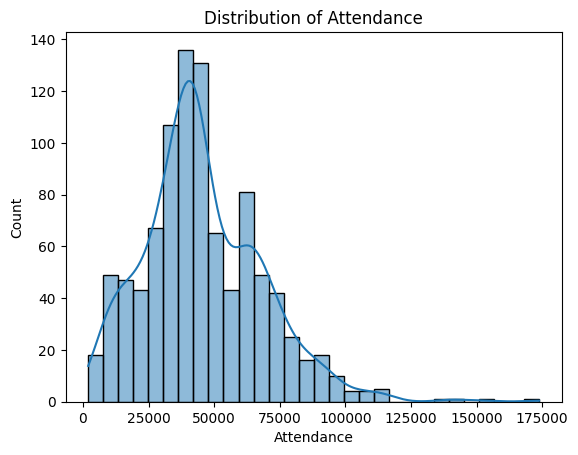

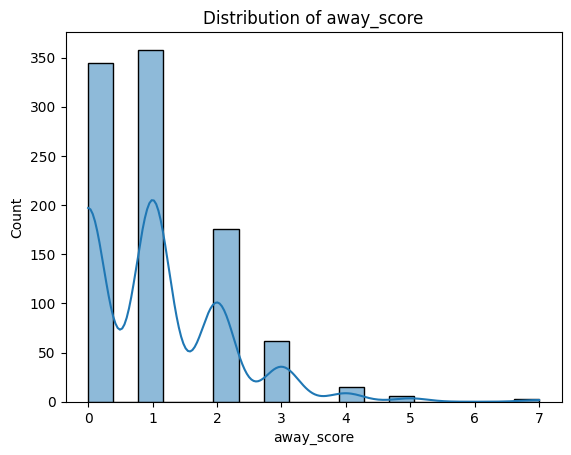

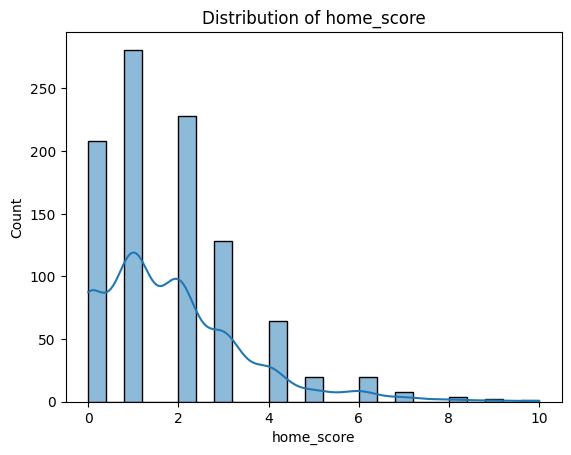

In [10]:
# Define host status at the start of EDA for consistent use
df['is_host'] = df['home_team'] == df['Host']

numerical_cols = ['Attendance','away_score','home_score']
for column in numerical_cols:
  sns.histplot(df[column], kde=True)
  plt.title(f'Distribution of {column}')
  plt.show()

There is a great differnce in the capacity of different stadiums and attendance rate which indicates that some popular matches have an outstanding attendace rate

### Is there a difference in the rate of goal scoring for home and away teams?

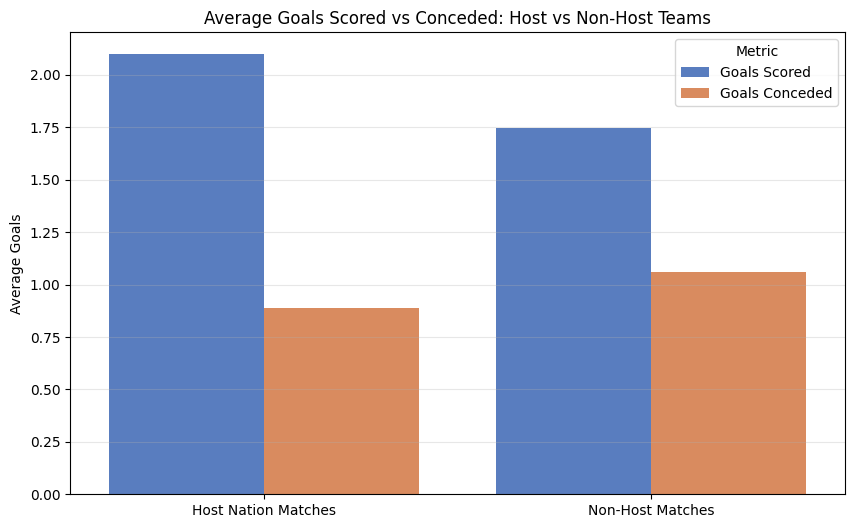

In [11]:
host_matches = df[df['is_host'] == True]
host_stats = {
    'Group': 'Host Nation Matches',
    'Goals Scored': host_matches['home_score'].mean(),
    'Goals Conceded': host_matches['away_score'].mean()
}

# Calculate averages for Non-Host Matches
non_host_matches = df[df['is_host'] == False]
non_host_stats = {
    'Group': 'Non-Host Matches',
    'Goals Scored': non_host_matches['home_score'].mean(),
    'Goals Conceded': non_host_matches['away_score'].mean()
}

# Combine into a plotting dataframe
plot_df = pd.DataFrame([host_stats, non_host_stats])
plot_df = plot_df.melt(id_vars='Group', var_name='Metric', value_name='Average Goals')

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Group', y='Average Goals', hue='Metric', data=plot_df, palette='muted')

plt.title('Average Goals Scored vs Conceded: Host vs Non-Host Teams')
plt.ylabel('Average Goals')
plt.xlabel('')
plt.grid(axis='y', alpha=0.3)
plt.show()

This shows that host teams have higher offensive and defensive performance

## Relation between attendance and host performance

The correlation between Host Nation Score and Attendance is: 0.1263


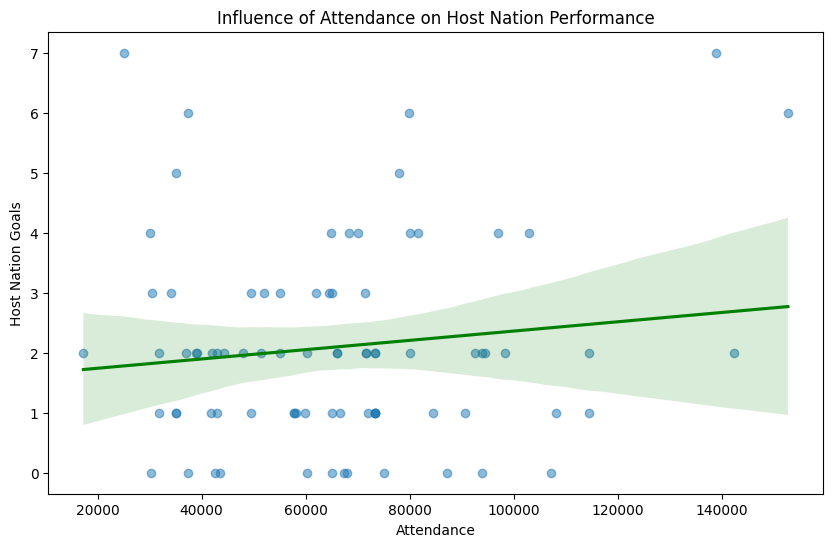

In [12]:
correlation = host_matches['home_score'].corr(host_matches['Attendance'])

print(f"The correlation between Host Nation Score and Attendance is: {correlation:.4f}")

# Visualizing the relationship for Hosts only
plt.figure(figsize=(10, 6))
sns.regplot(x='Attendance', y='home_score', data=host_matches, scatter_kws={'alpha':0.5}, line_kws={'color':'green'})
plt.title('Influence of Attendance on Host Nation Performance')
plt.ylabel('Host Nation Goals')
plt.show()

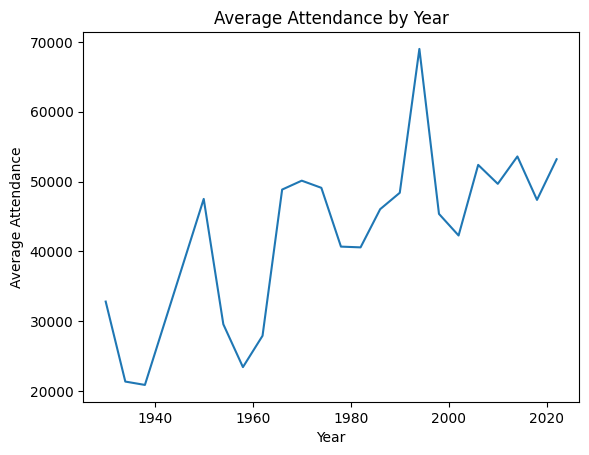

In [13]:
df.groupby('Year')['Attendance'].mean().plot()
plt.title('Average Attendance by Year')
plt.xlabel('Year')
plt.ylabel('Average Attendance')
plt.show()

there is an increase in the attendance rate over different world cups , this maybe due to the increase in facilties and comfort in stadiums

## Who are the managers with the best defensive and offensive performance?

In [14]:
# Combine home and away match data for managers
home_data = df[['home_manager', 'home_score', 'away_score']].rename(columns={'home_manager': 'manager', 'home_score': 'scored', 'away_score': 'conceded'})
away_data = df[['away_manager', 'away_score', 'home_score']].rename(columns={'away_manager': 'manager', 'away_score': 'scored', 'home_score': 'conceded'})
manager_stats = pd.concat([home_data, away_data])

# Group by manager and filter for those with at least 5 matches
manager_performance = manager_stats.groupby('manager').agg(
    matches_played=('manager', 'count'),
    avg_scored=('scored', 'mean'),
    avg_conceded=('conceded', 'mean')
)

# Filter for managers with a minimum number of matches to ensure significance
min_matches = 5
qualified_managers = manager_performance[manager_performance['matches_played'] >= min_matches]

# Get top 2 Offensive Managers
top_offensive = qualified_managers.sort_values(by='avg_scored', ascending=False).head(2)

# Get top 2 Defensive Managers
top_defensive = qualified_managers.sort_values(by='avg_conceded', ascending=True).head(2)

print("Top 2 Offensive Managers (Avg Goals Scored per Match):")
display(top_offensive[['matches_played', 'avg_scored']])

print("\nTop 2 Defensive Managers (Avg Goals Conceded per Match):")
display(top_defensive[['matches_played', 'avg_conceded']])

Top 2 Offensive Managers (Avg Goals Scored per Match):


,matches_played,avg_scored
manager,,
Gusztav Sebes,5,5.400000
Albert Batteaux,6,3.833333



Top 2 Defensive Managers (Avg Goals Conceded per Match):


,matches_played,avg_conceded
manager,,
Ron Greenwood,5,0.200000
Aimé Jacquet,7,0.285714


## Do refrees tend to help host teams and get biased towards them?

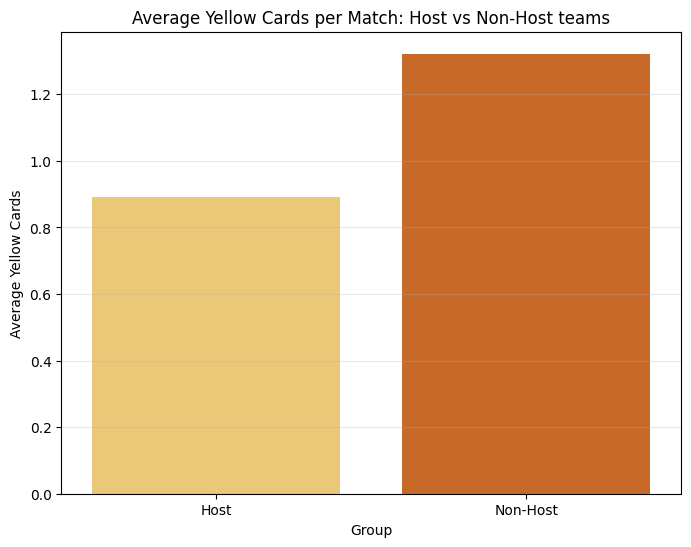

In [15]:
# Yellow Cards: Count occurrences of events in the yellow card specific column
# Using the count of '|' as a proxy for the number of events in the string
host_yellow = host_matches['home_yellow_card_long'].apply(lambda x: x.count('|') // 2 if x else 0).mean()
non_host_yellow = non_host_matches['home_yellow_card_long'].apply(lambda x: x.count('|') // 2 if x else 0).mean()

# Prepare DataFrame for yellow cards only
plot_data = pd.DataFrame({
    'Group': ['Host', 'Non-Host'],
    'Avg Yellow Cards': [host_yellow, non_host_yellow]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Group', y='Avg Yellow Cards', data=plot_data, palette='YlOrBr')
plt.title('Average Yellow Cards per Match: Host vs Non-Host teams')
plt.ylabel('Average Yellow Cards')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Predictive Modeling

### Attendance Prediction (Regression)
We will now use an XGBoost Regressor to predict the `Attendance`. This can help identify which factors (like specific teams or the era of the tournament) most influence ticket sales.

Mean Absolute Error: 12191.20
Root Mean Squared Error: 17958.67
R-squared Score: 0.4228


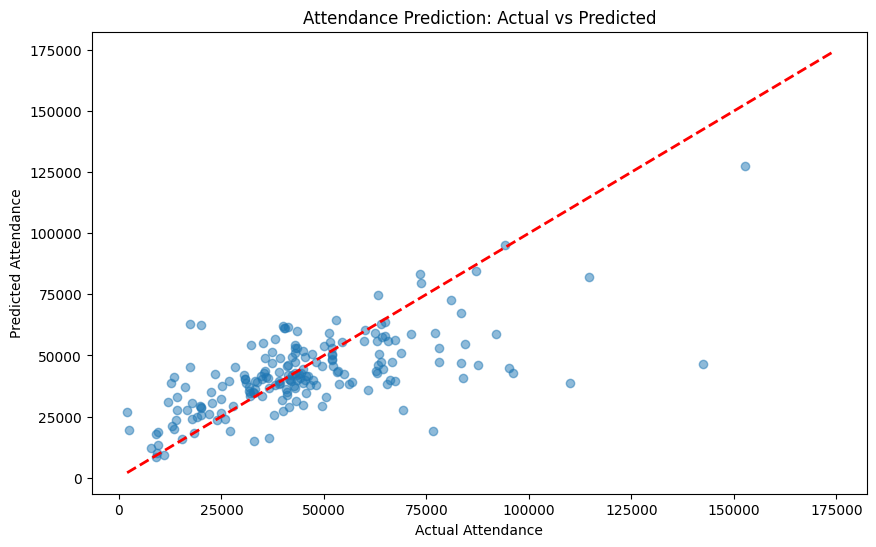

In [16]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Feature Selection & Encoding
features_reg = ['home_team', 'away_team', 'Year', 'Round', 'is_host']
X_reg = df[features_reg].copy()
y_reg = df['Attendance']

# Encode categorical features
le_team = LabelEncoder()
all_teams = pd.concat([X_reg['home_team'], X_reg['away_team']]).unique()
le_team.fit(all_teams)
X_reg['home_team'] = le_team.transform(X_reg['home_team'])
X_reg['away_team'] = le_team.transform(X_reg['away_team'])

le_round = LabelEncoder()
X_reg['Round'] = le_round.fit_transform(X_reg['Round'])
X_reg['is_host'] = X_reg['is_host'].astype(int)

# 2. Split Data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 3. Train XGBoost Regressor
reg_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
reg_model.fit(X_train_reg, y_train_reg)


y_pred_reg = reg_model.predict(X_test_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Plotting Predicted vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Attendance')
plt.ylabel('Predicted Attendance')
plt.title('Attendance Prediction: Actual vs Predicted')
plt.show()

# Improving Attendance Prediction Accuracy

we will try to improve the model by feature engineering, data preprocessing ,etc...

We will make historical accumulative features

In [25]:
def build_features(df):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    # (match importance)
    round_map = {
        'Group stage play-off': 0, 'First round': 1, 'First group stage': 1,
        'Group stage': 1, 'Second group stage': 2, 'Second round': 3,
        'Round of 16': 3, 'Quarter-finals': 4, 'Semi-finals': 5,
        'Third-place match': 5.5, 'Final stage': 5, 'Final': 6,
    }
    df['round_importance'] = df['Round'].map(round_map).fillna(1)
    df['is_knockout'] = (df['round_importance'] >= 3).astype(int)
    df['is_final'] = (df['Round'] == 'Final').astype(int)

    # --- Venue / City ---
    df['City'] = df['Venue'].str.split(',').str[-1].str.strip()

    # --- Time-safe expanding (historical, no leakage) features ---
    df['venue_hist_avg_att'] = (
        df.groupby('Venue')['Attendance']
          .transform(lambda s: s.shift(1).expanding().mean())
    )
    df['city_hist_avg_att'] = (
        df.groupby('City')['Attendance']
          .transform(lambda s: s.shift(1).expanding().mean())
    )

    # team "draw power": historical avg attendance in matches team was involved in
    long = pd.concat([
        df[['Date','home_team','Attendance']].rename(columns={'home_team':'team'}),
        df[['Date','away_team','Attendance']].rename(columns={'away_team':'team'}),
    ]).sort_values('Date').reset_index(drop=True)
    long['team_hist_avg_att'] = (
        long.groupby('team')['Attendance']
            .transform(lambda s: s.shift(1).expanding().mean())
    )
    long['team_match_count'] = long.groupby('team').cumcount()
    long_unique = long.drop_duplicates(subset=['Date','team'], keep='last')
    team_hist = long_unique.set_index(['Date','team'])[['team_hist_avg_att','team_match_count']]

    df['home_team_hist_avg_att'] = df.set_index(['Date','home_team']).index.map(team_hist['team_hist_avg_att'].to_dict())
    df['away_team_hist_avg_att'] = df.set_index(['Date','away_team']).index.map(team_hist['team_hist_avg_att'].to_dict())
    # Fill NaNs for team experience features
    df['home_team_experience'] = df.set_index(['Date','home_team']).index.map(team_hist['team_match_count'].to_dict()).fillna(0)
    df['away_team_experience'] = df.set_index(['Date','away_team']).index.map(team_hist['team_match_count'].to_dict()).fillna(0)

    # global expanding mean as fallback / overall time trend feature
    df['global_hist_avg_att'] = df['Attendance'].shift(1).expanding().mean()

    for col in ['venue_hist_avg_att','city_hist_avg_att','home_team_hist_avg_att',
                'away_team_hist_avg_att','global_hist_avg_att']:
        df[col] = df[col].fillna(df['global_hist_avg_att'].median())
    df['global_hist_avg_att'] = df['global_hist_avg_att'].fillna(df['Attendance'].median())

    # --- Team strength (keep given avg-goals features if present) ---
    if 'home_team_avg_goals' not in df.columns:
        df['home_team_avg_goals'] = np.nan
    if 'away_team_avg_goals' not in df.columns:
        df['away_team_avg_goals'] = np.nan

    # Fill NaNs for avg_goals before calculating difference, default to 0 if not present
    df['home_team_avg_goals'] = df['home_team_avg_goals'].fillna(0)
    df['away_team_avg_goals'] = df['away_team_avg_goals'].fillna(0)

    df['goal_strength_diff'] = df['home_team_avg_goals'] - df['away_team_avg_goals']

    # Fill any NaNs that might result from goal_strength_diff if both were NaN and not caught above
    df['goal_strength_diff'] = df['goal_strength_diff'].fillna(0)

    # --- Popularity: historically dominant footballing nations draw bigger crowds ---
    big_teams = {'Brazil','Germany','Argentina','Italy','France','England','Spain',
                 'Netherlands','Portugal','Uruguay'}
    df['home_big_team'] = df['home_team'].isin(big_teams).astype(int)
    df['away_big_team'] = df['away_team'].isin(big_teams).astype(int)
    df['big_match'] = ((df['home_big_team']==1) & (df['away_big_team']==1)).astype(int)

    # --- Host boost (host nation matches sell out) ---
    if 'is_host' not in df.columns:
        df['is_host'] = df['home_team'] == df['Host']
    df['is_host'] = df['is_host'].astype(int)
    df['away_is_host'] = (df['away_team'] == df['Host']).astype(int)
    df['host_involved'] = ((df['is_host']==1) | (df['away_is_host']==1)).astype(int)

    # --- Date parts ---
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['decade'] = (df['Year']//10)*10

    return df

df_feat = build_features(df)
df_feat.shape

(964, 48)

## Trying different models

In [20]:
!pip install catboost
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [28]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

num_features = [
    'Year','Month','DayOfWeek','round_importance','is_knockout','is_final',
    'venue_hist_avg_att','city_hist_avg_att','home_team_hist_avg_att',
    'away_team_hist_avg_att','home_team_experience','away_team_experience',
    'global_hist_avg_att','home_team_avg_goals','away_team_avg_goals',
    'goal_strength_diff','home_big_team','away_big_team','big_match',
    'is_host','away_is_host','host_involved'
]
cat_features = ['home_team','away_team','Venue','Referee','Round','City']

X = df_feat[num_features + cat_features].copy()
y = df_feat['Attendance'].copy()
for c in cat_features:
    X[c] = LabelEncoder().fit_transform(X[c].astype(str))

# --- Diagnostic: Check for NaNs before splitting and training ---
missing_in_X = X.isnull().sum()
missing_in_X = missing_in_X[missing_in_X > 0]
if not missing_in_X.empty:
    print("!!! WARNING: NaN values found in X before model training !!!")
    print(missing_in_X)
else:
    print("No NaN values found in X. Proceeding with training.")
# --- End Diagnostic ---

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate(name, model, log_target=False):
    if log_target:
        model.fit(X_train, np.log1p(y_train))
        pred = np.expm1(model.predict(X_test))
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{name:32s} MAE={mae:9.2f}  RMSE={rmse:9.2f}  R2={r2:.4f}")
    return model

print("=== Improved features: raw target ===")
evaluate('RandomForest', RandomForestRegressor(n_estimators=400, max_depth=8, min_samples_leaf=3, random_state=42))
evaluate('GradientBoosting', GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42))
evaluate('XGBoost', XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42))
evaluate('LightGBM', LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1))
evaluate('CatBoost', CatBoostRegressor(n_estimators=300, depth=4, learning_rate=0.05, random_state=42, verbose=0))


print("=== Improved features: log1p(target) ===")
evaluate('XGBoost (log target)', XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42), log_target=True)
evaluate('LightGBM (log target)', LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1), log_target=True)
evaluate('CatBoost (log target)', CatBoostRegressor(n_estimators=300, depth=4, learning_rate=0.05, random_state=42, verbose=0), log_target=True)

No NaN values found in X. Proceeding with training.
=== Improved features: raw target ===
RandomForest                     MAE=  8165.22  RMSE= 14929.22  R2=0.6029
GradientBoosting                 MAE=  8388.28  RMSE= 14422.18  R2=0.6294
XGBoost                          MAE=  8234.93  RMSE= 14108.26  R2=0.6453
LightGBM                         MAE=  7918.59  RMSE= 13412.90  R2=0.6794
CatBoost                         MAE=  8142.93  RMSE= 13652.72  R2=0.6679

=== Improved features: log1p(target) ===
XGBoost (log target)             MAE=  8403.06  RMSE= 14945.67  R2=0.6020
LightGBM (log target)            MAE=  8376.88  RMSE= 14755.52  R2=0.6120
CatBoost (log target)            MAE=  8620.63  RMSE= 14562.17  R2=0.6221


CatBoostRegressor(depth=4, learning_rate=0.05, loss_function='RMSE', n_estimators=300, random_state=42, verbose=0)

feature engineering made a huge difference, but log transform didn't make a difference

## 4. Cross-validation (more reliable than one split)

With only 964 rows, a single train/test split is noisy. We use 5-fold CV to get a stable estimate of how each model generalizes.

In [29]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Diagnostic: Check for NaNs in X before cross-validation
nan_cols_cv = X.isnull().sum()
nan_cols_cv = nan_cols_cv[nan_cols_cv > 0]
if not nan_cols_cv.empty:
    print(f"!!! ERROR: NaN values found in X before cross-validation in columns:\n{nan_cols_cv}")
    raise ValueError("NaN values detected in X. Cannot proceed with cross-validation.")
else:
    print("No NaN values found in X before cross-validation. Proceeding.")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'RandomForest': RandomForestRegressor(n_estimators=400, max_depth=8, min_samples_leaf=3, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1),
    'CatBoost': CatBoostRegressor(n_estimators=300, depth=4, learning_rate=0.05, random_state=42, verbose=0),
}

print(f"{'Model':20s} {'CV R2 mean':>12s} {'CV R2 std':>10s} {'CV MAE mean':>12s}")
for name, model in models.items():
    cv = cross_validate(model, X, y, cv=kf, scoring=('r2','neg_mean_absolute_error'))
    print(f"{name:20s} {cv['test_r2'].mean():12.4f} {cv['test_r2'].std():10.4f} {-cv['test_neg_mean_absolute_error'].mean():12.2f}")

No NaN values found in X before cross-validation. Proceeding.
Model                  CV R2 mean  CV R2 std  CV MAE mean
RandomForest               0.7157     0.0586      7067.62
GradientBoosting           0.7235     0.0526      7306.15
XGBoost                    0.7475     0.0547      6991.85
LightGBM                   0.7416     0.0362      7190.62
CatBoost                   0.7360     0.0414      7180.45


## 5. Hyperparameter tuning

Randomized search (5-fold CV, scored on R²) over XGBoost, LightGBM, CatBoost and Random Forest. (Search spaces trimmed a bit for runtime; feel free to widen `n_iter` / the grids.)

In [30]:
from sklearn.model_selection import RandomizedSearchCV

xgb_grid = {'n_estimators':[150,200,300,400],'max_depth':[3,4,5,6],
            'learning_rate':[0.02,0.05,0.08,0.1],'subsample':[0.7,0.8,0.9,1.0],
            'colsample_bytree':[0.7,0.8,0.9,1.0],'min_child_weight':[1,3,5],
            'reg_alpha':[0,0.5,1],'reg_lambda':[0.5,1,2]}
xgb_search = RandomizedSearchCV(XGBRegressor(random_state=42, n_jobs=1), xgb_grid, n_iter=25, cv=kf,
                                 scoring='r2', random_state=42, n_jobs=1)
xgb_search.fit(X, y)
print("Best XGB R2:", xgb_search.best_score_, xgb_search.best_params_)

Best XGB R2: 0.7521100401878357 {'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.08, 'colsample_bytree': 0.7}


In [31]:
lgb_grid = {'n_estimators':[150,200,300,400],'max_depth':[3,4,5,6,-1],
            'learning_rate':[0.02,0.05,0.08,0.1],'subsample':[0.7,0.8,0.9,1.0],
            'colsample_bytree':[0.7,0.8,0.9,1.0],'num_leaves':[15,31,63],
            'min_child_samples':[5,10,20,30]}
lgb_search = RandomizedSearchCV(LGBMRegressor(random_state=42, verbosity=-1, n_jobs=1), lgb_grid, n_iter=25, cv=kf,
                                 scoring='r2', random_state=42, n_jobs=1)
lgb_search.fit(X, y)
print("Best LGBM R2:", lgb_search.best_score_, lgb_search.best_params_)

Best LGBM R2: 0.7402587747785775 {'subsample': 0.9, 'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 5, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [32]:
cat_grid = {'n_estimators':[150,200,300],'depth':[3,4,5,6],
            'learning_rate':[0.02,0.05,0.08,0.1],'l2_leaf_reg':[1,3,5,7,9]}
cat_search = RandomizedSearchCV(CatBoostRegressor(random_state=42, verbose=0, thread_count=1), cat_grid, n_iter=16, cv=kf,
                                 scoring='r2', random_state=42, n_jobs=1)
cat_search.fit(X, y)
print("Best CatBoost R2:", cat_search.best_score_, cat_search.best_params_)

Best CatBoost R2: 0.7350168171002679 {'n_estimators': 300, 'learning_rate': 0.08, 'l2_leaf_reg': 7, 'depth': 4}


In [33]:
rf_grid = {'n_estimators':[200,300,400,600],'max_depth':[5,6,8,10,12,None],
           'min_samples_leaf':[1,2,3,5,8],'max_features':['sqrt','log2',0.5,0.8]}
rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=1), rf_grid, n_iter=20, cv=kf,
                                scoring='r2', random_state=42, n_jobs=1)
rf_search.fit(X, y)
print("Best RF R2:", rf_search.best_score_, rf_search.best_params_)

Best RF R2: 0.7344579330476209 {'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}


## Ensembling.

In [34]:
from sklearn.ensemble import VotingRegressor, StackingRegressor

xgb_best = xgb_search.best_estimator_
lgb_best = lgb_search.best_estimator_
cat_best = cat_search.best_estimator_
rf_best  = rf_search.best_estimator_

voting = VotingRegressor([('xgb',xgb_best),('lgb',lgb_best),('cat',cat_best),('rf',rf_best)])
cv_v = cross_validate(voting, X, y, cv=kf, scoring=('r2','neg_mean_absolute_error'))
print(f"Voting Ensemble   R2={cv_v['test_r2'].mean():.4f} (+/-{cv_v['test_r2'].std():.4f})  MAE={-cv_v['test_neg_mean_absolute_error'].mean():.2f}")

stack = StackingRegressor(estimators=[('xgb',xgb_best),('lgb',lgb_best),('cat',cat_best),('rf',rf_best)],
                           final_estimator=Ridge(alpha=1.0), cv=kf)
cv_s = cross_validate(stack, X, y, cv=kf, scoring=('r2','neg_mean_absolute_error'))
print(f"Stacking Ensemble R2={cv_s['test_r2'].mean():.4f} (+/-{cv_s['test_r2'].std():.4f})  MAE={-cv_s['test_neg_mean_absolute_error'].mean():.2f}")

for name, m in [('XGB tuned',xgb_best),('LGB tuned',lgb_best),('Cat tuned',cat_best),('RF tuned',rf_best)]:
    cvi = cross_validate(m, X, y, cv=kf, scoring=('r2','neg_mean_absolute_error'))
    print(f"{name:16s} R2={cvi['test_r2'].mean():.4f} (+/-{cvi['test_r2'].std():.4f})  MAE={-cvi['test_neg_mean_absolute_error'].mean():.2f}")

Voting Ensemble   R2=0.7528 (+/-0.0424)  MAE=6773.09
Stacking Ensemble R2=0.7534 (+/-0.0438)  MAE=6803.15
XGB tuned        R2=0.7521 (+/-0.0442)  MAE=7022.64
LGB tuned        R2=0.7403 (+/-0.0378)  MAE=7074.60
Cat tuned        R2=0.7350 (+/-0.0415)  MAE=7274.96
RF tuned         R2=0.7345 (+/-0.0483)  MAE=6881.40


##  Feature importance

What's actually driving predicted attendance, per the tuned XGBoost model?

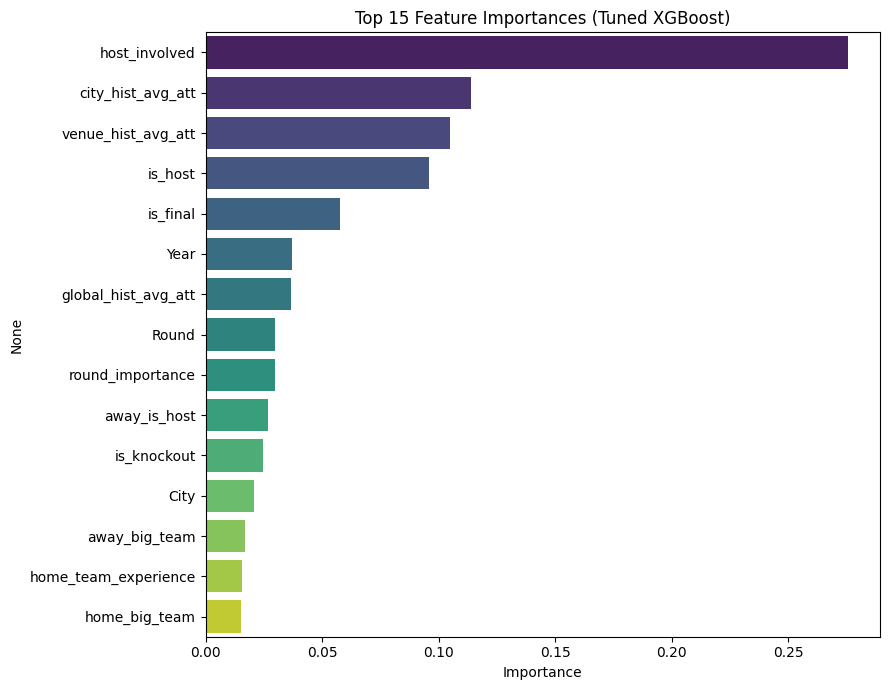

In [36]:
importances = pd.Series(xgb_best.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(9,7))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, palette='viridis')
plt.title('Top 15 Feature Importances (Tuned XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()